# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [273]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

In [274]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("C:\CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [275]:

for col in df.select_dtypes(include='object'):
    print(col)
    print(df[col].unique())
    print()

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age'] = df['Age'].astype(int)

df['Income'] = df['Income'].replace('[\$,]', '', regex=True)  

df['Income'] = pd.to_numeric(df['Income'])

df['Gender'] = df['Gender'].str.strip()
df['Education'] = df['Education'].str.strip()
df['Marital Status'] = df['Marital Status'].str.strip()
df['Home Ownership'] = df['Home Ownership'].str.strip()

df['Gender'] = df['Gender'].str.title()
df['Education'] = df['Education'].str.title()
df['Marital Status'] = df['Marital Status'].str.title()
df['Home Ownership'] = df['Home Ownership'].str.title()


credit_map = {
    'Low': 1,
    'Average': 2,
    'High': 3
}

df['Credit Score'] = df['Credit Score'].map(credit_map)


df.info()
df.isnull().sum()


Gender
['Female' 'Male']

Income
['50.000,00' '100.000,00' '75.000,00' '125.000,00' '150.000,00'
 '40.000,00' '60.000,00' '80.000,00' '105.000,00' '90.000,00' '135.000,00'
 '35.000,00' '55.000,00' '70.000,00' '95.000,00' '85.000,00' '30.000,00'
 '65.000,00' '115.000,00' '25.000,00' '45.000,00' '130.000,00'
 '155.000,00' '110.000,00' '140.000,00' '37.500,00' '57.500,00'
 '72.500,00' '32.500,00' '52.500,00' '67.500,00' '92.500,00' '82.500,00'
 '122.500,00' '27.500,00' '47.500,00' '62.500,00' '87.500,00' '77.500,00'
 '112.500,00' '117.500,00' '142.500,00' '160.000,00' '97.500,00'
 '145.000,00' '162.500,00' '120.000,00' '102.500,00' '137.500,00'
 '127.500,00' '82.000,00' '68.000,00']

Education
["Bachelor's Degree" "Master's Degree" 'Doctorate' 'High School Diploma'
 "Associate's Degree"]

Marital Status
['Single' 'Married']

Home Ownership
['Rented' 'Owned']

Credit Score
['High' 'Average' 'Low']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 

Age                   0
Gender                0
Income                0
Education             0
Marital Status        0
Number of Children    0
Home Ownership        0
Credit Score          0
dtype: int64

**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [276]:
#Na analise vi que tinha dados faltantes na coluna Age, resolvi mudar pela Média pois assim mantem a distribuição dos dados e evita distorções significativas

**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [277]:
colunas_categoricas = ['Gender', 'Education', 'Marital Status', 'Home Ownership', 'Credit Score']

for col in colunas_categoricas:
    print(col)
    print(df[col].unique())
    print()

Gender
['Female' 'Male']

Education
["Bachelor'S Degree" "Master'S Degree" 'Doctorate' 'High School Diploma'
 "Associate'S Degree"]

Marital Status
['Single' 'Married']

Home Ownership
['Rented' 'Owned']

Credit Score
[3 2 1]



# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

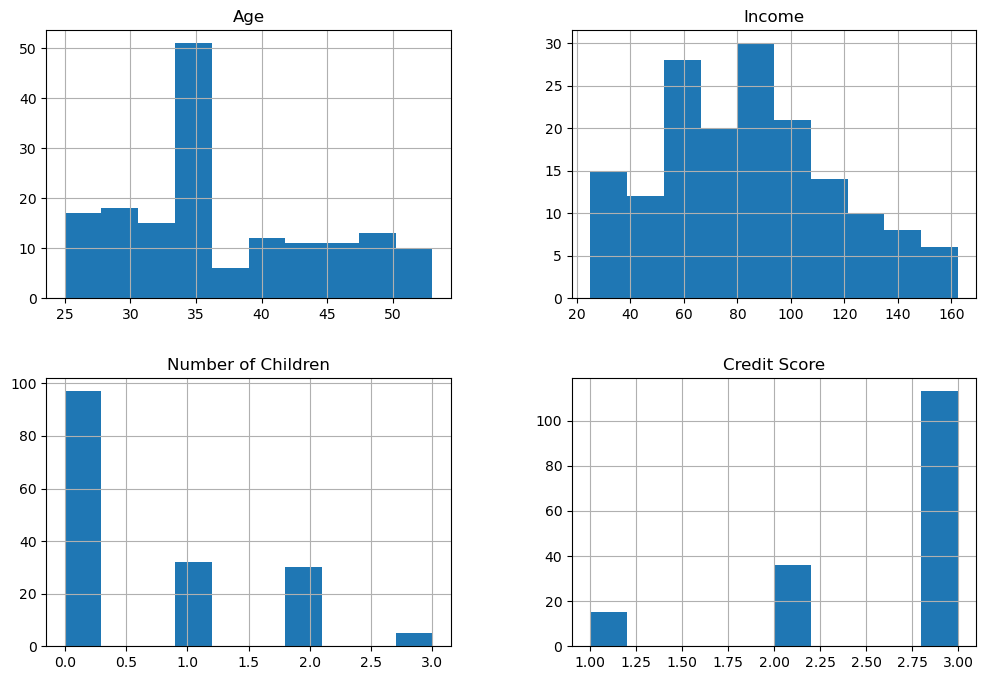

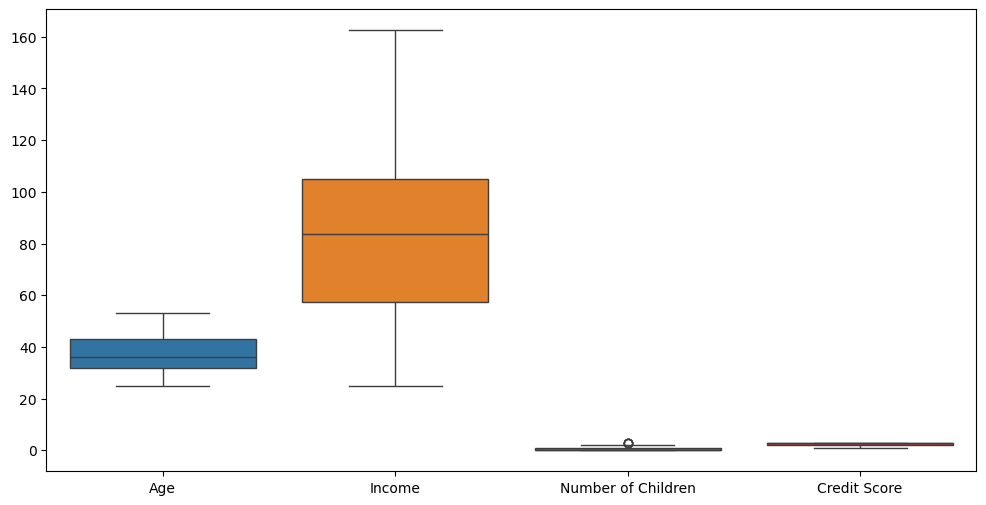

In [278]:
df.describe()


df.hist(figsize=(12,8))
plt.show()



plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.show()



**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

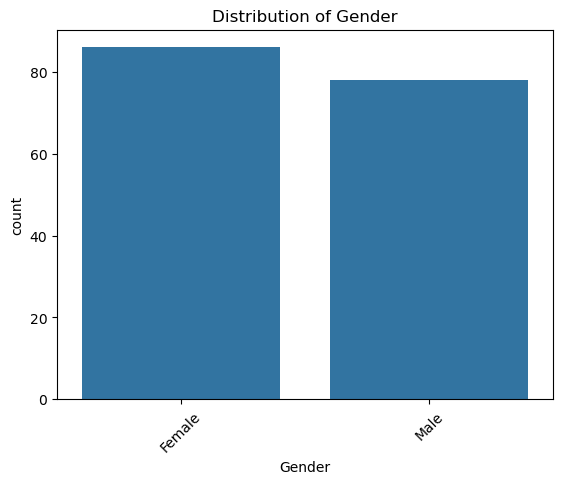

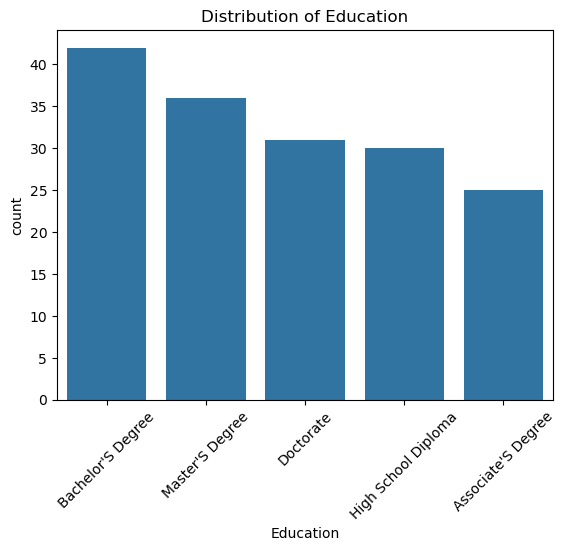

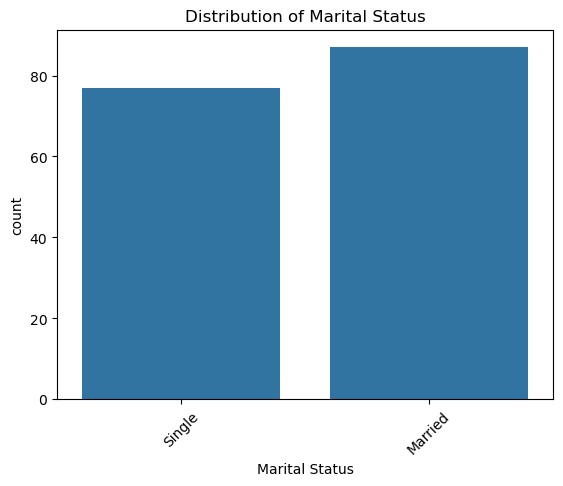

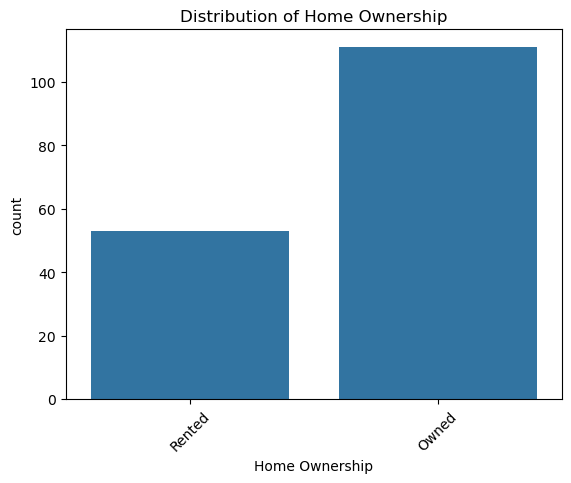

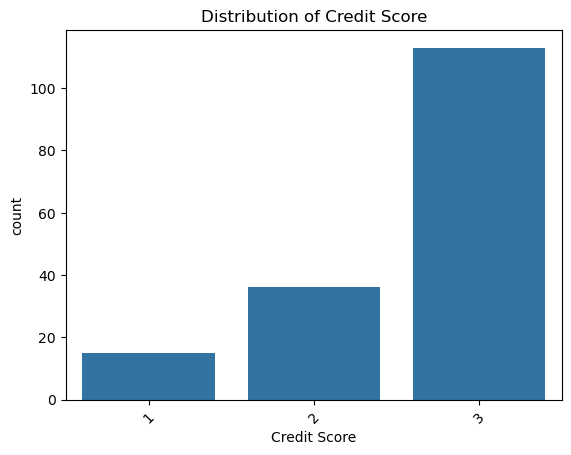

In [279]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_columns = [
    'Gender',
    'Education',
    'Marital Status',
    'Home Ownership',
    'Credit Score'
]

for col in categorical_columns:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

In [280]:
#Não

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



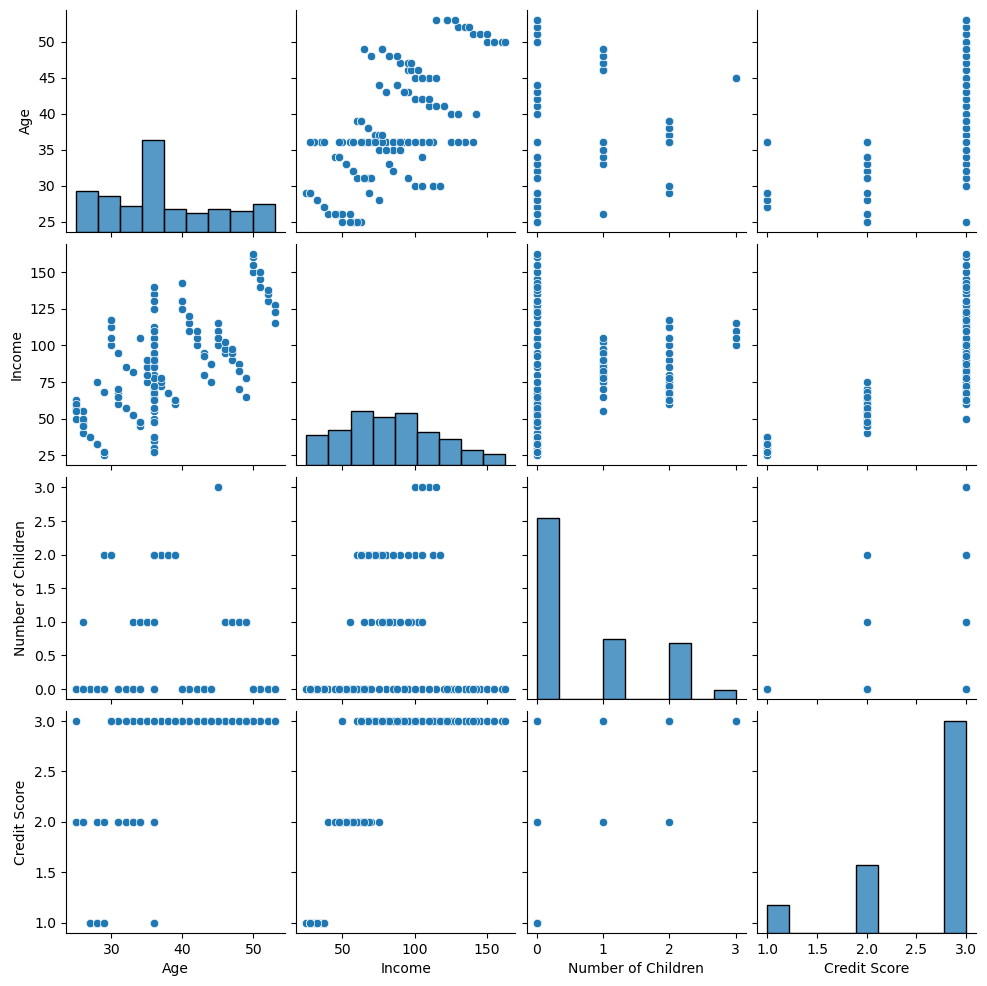

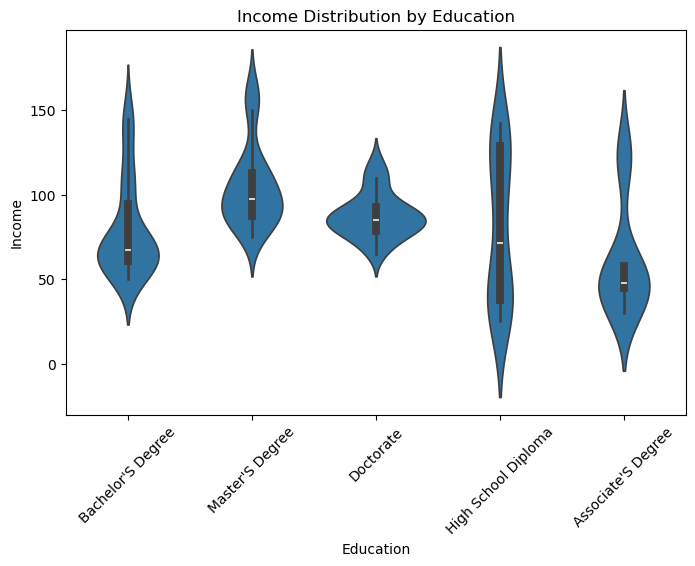

In [281]:
sns.pairplot(df[['Age','Income','Number of Children','Credit Score']])
plt.show()

plt.figure(figsize=(8,5))
sns.violinplot(x='Education', y='Income', data=df)
plt.xticks(rotation=45)
plt.title('Income Distribution by Education')
plt.show()

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

In [282]:
# Numero de filhos esta ligado com a renda? Sim, quanto mais filhos maior a renda da Familia com isso o score é maior
# Numero de filhos com renda e score? Quanto maior o numero de filhos maior é a renda mas o grafico mostra tambem e pessoas sem filhos tem uma renda muito grande e com isso score alto
# Maior diferença de renda? Com os grafico vimos que existe uma variação maior de renda entre 30 a 40 anos
 

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

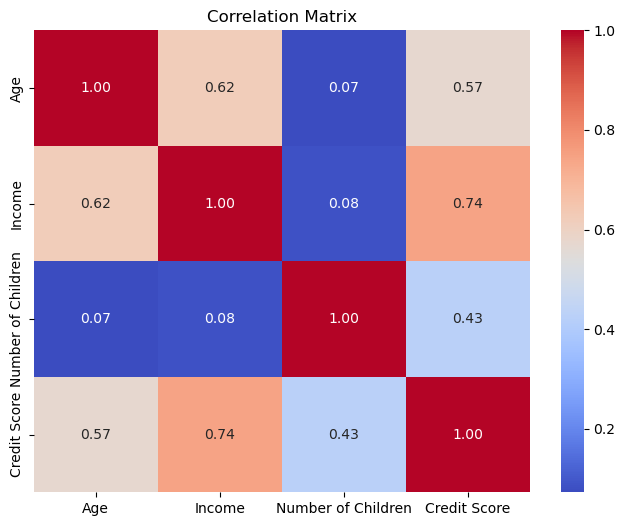

In [283]:
df[['Age','Income','Number of Children','Credit Score']].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Age','Income','Number of Children','Credit Score']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title('Correlation Matrix')
plt.show()

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

In [284]:
# Existe uma alta correlação entre renda e Score o que faz muito sentido, o grafico mostra tambem uma corelação interessante em idade com score e renda. Ha uma relação entre numero de filhos com dredito que merece uma atenção e pode ser estudado

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [285]:
df_encoded = pd.get_dummies(
    df,
    columns=['Gender','Education','Marital Status','Home Ownership'],
    drop_first=True
)

**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

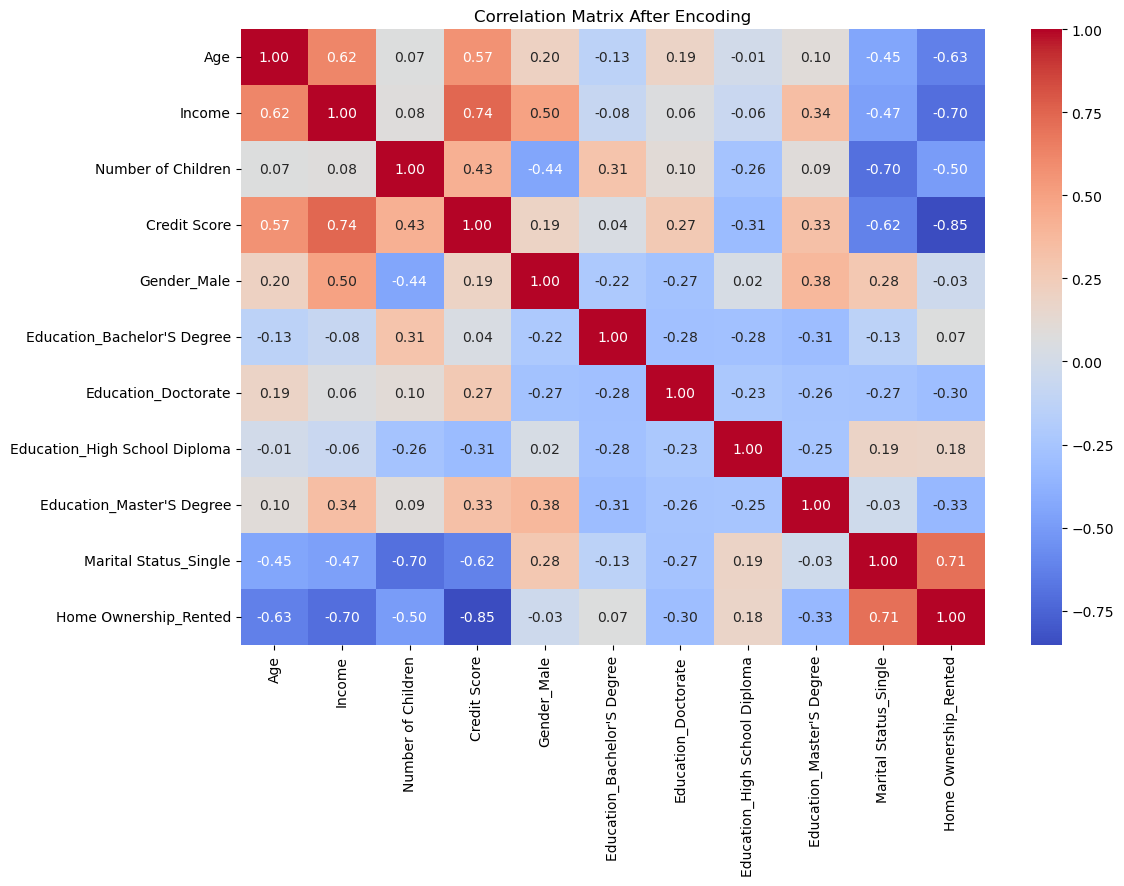

In [286]:
corr_matrix = df_encoded.corr()
corr_matrix

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title('Correlation Matrix After Encoding')
plt.show()

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [287]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Credit Score', axis=1)
y = df_encoded['Credit Score']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)



(131, 10)
(33, 10)
(131,)
(33,)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

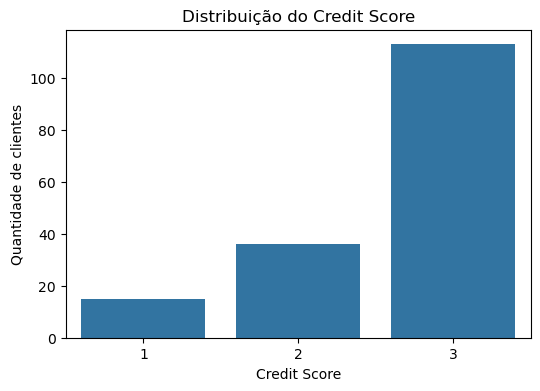

In [288]:
df['Credit Score'].value_counts()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x='Credit Score', data=df)

plt.title('Distribuição do Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Quantidade de clientes')

plt.show()

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

In [289]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Antes do balanceamento:")
print(X_train.shape)
print(y_train.shape)

print("\nDepois do balanceamento:")
print(X_train_bal.shape)
print(y_train_bal.shape)

print(y_train_bal.value_counts())



Antes do balanceamento:
(131, 10)
(131,)

Depois do balanceamento:
(270, 10)
(270,)
Credit Score
3    90
2    90
1    90
Name: count, dtype: int64
